# Summer '26
## Author: Zane Collins
## Last Updated: 06/17/2026


# Imports

In [1]:
from hapi import *

HAPI version: 1.3.0.0
To get the most up-to-date version please check http://hitran.org/hapi
ATTENTION: Python versions of partition sums from TIPS-2021 are now available in HAPI code

           MIT license: Copyright 2021 HITRAN team, see more at http://hitran.org. 

           If you use HAPI in your research or software development,
           please cite it using the following reference:
           R.V. Kochanov, I.E. Gordon, L.S. Rothman, P. Wcislo, C. Hill, J.S. Wilzewski,
           HITRAN Application Programming Interface (HAPI): A comprehensive approach
           to working with spectroscopic data, J. Quant. Spectrosc. Radiat. Transfer 177, 15-30 (2016)
           DOI: 10.1016/j.jqsrt.2016.03.005

           ATTENTION: This is the core version of the HITRAN Application Programming Interface.
                      For more efficient implementation of the absorption coefficient routine, 
                      as well as for new profiles, parameters and other functional,
      

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import glob
import os
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
from matplotlib.colors import to_rgba
from matplotlib.colors import LinearSegmentedColormap
import pandas as pd
import pickle
import seaborn as sns

from scipy.signal import correlate


# imp
os.chdir('/Users/zaniaccollins/Research/SGL/sgl_science_case/')
from bin_spec import bin_spectrum
from exo_spec_simv2 import *
from exo_spec_simv2 import run_cross_correlation
os.chdir('/Users/zaniaccollins/Research/SGL/sgl_science_case/notebooks')
%matplotlib widget

In [3]:
os.getcwd()

'/Users/zaniaccollins/Research/SGL/sgl_science_case/notebooks'

# Parsing

In [4]:
data_dir = '../data'

In [5]:
db_begin("HAPI_DB");

Using HAPI_DB

CH4
                     Lines parsed: 9009
CH4_iso2
                     Lines parsed: 25360
H2O_iso3
                     Lines parsed: 1787
H2O_iso1
                     Lines parsed: 10337
CH4_iso1
                     Lines parsed: 45455
H2O
                     Lines parsed: 15602
H2O_iso2
                     Lines parsed: 2485


In [6]:
tableList()

dict_keys(['sampletab', 'CH4', 'CH4_iso2', 'H2O_iso3', 'H2O_iso1', 'CH4_iso1', 'H2O', 'H2O_iso2'])

In [90]:
wl_min = 3.1
wl_max = 3.5
native_dwn = 0.001     # cm^-1, native HITRAN-resolution sampling (HAPI side)

wn_min = 1e4/wl_max
wn_max = 1e4/wl_min


## CH4 & Water Fetching

In [91]:
# Isotopes to download:
ch4_isotopes = [1,2]
h2o_isotopes = [1,2,3]

In [92]:
for isotope in ch4_isotopes:
    fetch(f"CH4_iso{isotope}", 6, isotope, wn_min, wn_max)
for isotope in h2o_isotopes:
    fetch(f"H2O_iso{isotope}", 1, isotope, wn_min, wn_max)


Data is fetched from http://hitran.org

BEGIN DOWNLOAD: CH4_iso1
  65536 bytes written to HAPI_DB/CH4_iso1.data
  65536 bytes written to HAPI_DB/CH4_iso1.data
  65536 bytes written to HAPI_DB/CH4_iso1.data
  65536 bytes written to HAPI_DB/CH4_iso1.data
  65536 bytes written to HAPI_DB/CH4_iso1.data
  65536 bytes written to HAPI_DB/CH4_iso1.data
  65536 bytes written to HAPI_DB/CH4_iso1.data
  65536 bytes written to HAPI_DB/CH4_iso1.data
  65536 bytes written to HAPI_DB/CH4_iso1.data
  65536 bytes written to HAPI_DB/CH4_iso1.data
  65536 bytes written to HAPI_DB/CH4_iso1.data
  65536 bytes written to HAPI_DB/CH4_iso1.data
  65536 bytes written to HAPI_DB/CH4_iso1.data
  65536 bytes written to HAPI_DB/CH4_iso1.data
  65536 bytes written to HAPI_DB/CH4_iso1.data
  65536 bytes written to HAPI_DB/CH4_iso1.data
  65536 bytes written to HAPI_DB/CH4_iso1.data
  65536 bytes written to HAPI_DB/CH4_iso1.data
  65536 bytes written to HAPI_DB/CH4_iso1.data
  65536 bytes written to HAPI_DB/CH4_iso1

# Helper Functions

In [118]:
def compute_transmission(molecule, isotope, dwn, T = 288, p = 1, column_density = 1e12, path_length = 1e5,scale_factor = 1.0):

    #Check if the molecule and isotope are in the database
    table_name = f"{molecule}_iso{isotope}"
    # if table_name not in [t[0] for t in tableList()]:
    #     raise ValueError(f"{molecule} with isotope {isotope} not found in database. Table {table_name}")
    
    #Fetch the absorption coefficients for the specified molecule and isotope
    wn_grid, coef = absorptionCoefficient_Voigt(
            Components=[(6, isotope, 1)],
            SourceTables=table_name,
            WavenumberRange=(wn_min, wn_max),
            WavenumberStep=dwn,
            Environment={'T': T, 'p': p} 
        )
    
    # Calculate the transmission using the Beer-Lambert law
    tau = coef * column_density * path_length

    tau *= scale_factor

    transmission = np.exp(-tau)

    wavelength_grid = 1e4 / wn_grid
    wavelength_grid
    resolution = np.median(wn_grid) / dwn

    return wavelength_grid, transmission, resolution

def generate_res_isotope_dict(molecules, isotopes_dict, dwns, 
                              T=288, p=1, column_density=1e12, 
                              path_length=1e5, scale_factor=1.0):
    """
    Generate nested dictionary: resolution -> molecule -> isotope -> data
    """
    res_dict = {}   # Main dictionary: res_key -> mol -> iso -> data
    
    for dwn in dwns:
        for mol in molecules:
            isotopes = isotopes_dict.get(mol, [])
            
            for iso in isotopes:
                # Compute the spectrum
                wl, trans, resolution = compute_transmission(
                    mol, iso, dwn, T, p, column_density, path_length, scale_factor
                )
                
                # Use clean integer key for resolution
                res_key = int(round(resolution))
                
                # Initialize nested structure if needed
                if res_key not in res_dict:
                    res_dict[res_key] = {}
                if mol not in res_dict[res_key]:
                    res_dict[res_key][mol] = {}
                
                # Store the data
                res_dict[res_key][mol][iso] = {
                    'wavelength_grid': wl,
                    'transmission': trans,
                    'resolution': resolution,      # keep float if you want
                    'dwn': dwn
                }
                
                print(f"Added: R={res_key} | {mol} iso{iso} | dwn={dwn}")
    
    return res_dict
        
def create_combined_transmission(data_dict, molecule_abundances, res, T=None, p=None, scale_factor=None):
    """
    molecule_abundances: dict[molecule] = dict[isotope] = fractional abundance (or column density scaling)
    Example: {'CH4': {1: 0.8, 2: 0.2}, 'H2O': {1: 1.0}}
    """
    tau_total = None
    wl_grid = None
    
    for mol, iso_abunds in molecule_abundances.items():
        for iso, frac in iso_abunds.items():
            # print(f'data_dict[{res}][{mol}][{iso}]')
            try:
                data = data_dict[res][mol][iso]
                current_wl = data['wavelength_grid']
                trans = data['transmission']
            except KeyError:
                print(f"Missing data for {mol} iso {iso} at res {res}")
                continue
                
            if wl_grid is None:
                wl_grid = current_wl
            
            tau = -np.log(np.clip(trans, 1e-10, 1.0))  # avoid log(0), tau = -ln(T) = -ln(exp(-tau)) = tau
            tau_total = tau * frac if tau_total is None else tau_total + tau * frac # Sum the optical depths weighted by their fractional abundances
    
    if tau_total is None:
        raise ValueError("No data found for any species")
    
    combined_trans = np.exp(-tau_total)
    return wl_grid, combined_trans


# Create binned dictionary
def create_binned_versions(parent_dict, R_values):
    """
    Take the high-res parent and bin it to multiple target resolutions.
    """
    binned_dict = {}   # resolution -> molecule -> isotope -> data
    
    for res_key in parent_dict.keys():           # usually just one fine resolution
        for mol in parent_dict[res_key].keys():
            for iso in parent_dict[res_key][mol].keys():
                data = parent_dict[res_key][mol][iso]
                wl_fine = data['wavelength_grid']
                trans_fine = data['transmission']
                
                for R in R_values:

                    # Ensure ascending wavelength order (critical for SpectRes)
                    sort_idx = np.argsort(wl_fine)
                    wl_fine = wl_fine[sort_idx]
                    trans_fine = trans_fine[sort_idx]

                    
                    wl_binned, trans_binned, _ = bin_spectrum(
                        wl_fine, trans_fine, R
                    )
                    
                    if R not in binned_dict:
                        binned_dict[R] = {}
                    if mol not in binned_dict[R]:
                        binned_dict[R][mol] = {}
                    
                    binned_dict[R][mol][iso] = {
                        'wavelength_grid': wl_binned,
                        'transmission': trans_binned,
                        'resolution': R,
                        'parent_resolution': res_key
                    }
                    
                    print(f"Binned {mol} iso{iso} to R = {R:,}")
    
    return binned_dict


# Noise injection
def inject_poisson_noise(data, SNR):

    signal = np.average(data)  # Representative signal level for scaling noise
    print(f"Average signal level: {signal:.4e}")
    scale = signal / SNR if signal > 0 else 1.0 
    print(f"scale factor: {scale:.4e} for SNR={SNR}")

    poisson_noise = np.random.poisson(lam=data)
    poisson_noise = poisson_noise - data  # Center the noise around zero
    
    noisy_data = data + poisson_noise * scale / np.sqrt(signal)  # Scale noise by SNR and signal level
    noisy_data = np.clip(noisy_data, 0, None)  # Ensure non-negative values

    errorbars = np.sqrt(data) * scale / np.sqrt(signal)  # Poisson noise error bars

    return noisy_data, errorbars

def inject_gaussian_noise(data, SNR, seed = 8):

    depth = 1.0 - data          # or np.abs(1.0 - data) if baseline isn't exactly 1
    signal_level = np.max(depth)   # Peak depth
    # signal_level = np.sqrt(np.mean(depth**2))   # RMS depth
    
    sigma = signal_level / SNR
    # print(f"Signal level: {signal_level:.4e}, Noise std dev: {sigma:.4e} for SNR={SNR}")

    nchan = len(data)
    rng = np.random.default_rng(seed)

    random_pertubations = sigma*rng.standard_normal(nchan)
    # print(f"Actual noise std: {random_pertubations.std():.4e} | Max |noise|: {np.abs(random_pertubations).max():.4e}")

    


    synthetic_atmosphere = data + random_pertubations 
    synthetic_atmosphere = np.clip(synthetic_atmosphere, 0, None) 
    
    errorbars = np.full_like(data, sigma) 
    return synthetic_atmosphere, errorbars

def run_full_isotope_cross_correlation(
    
    parent_dict,
    snr_values,
    resolution_values,
    abundance_scenarios,           # list of dicts: e.g. [{'CH4': {1: 0.95, 2: 0.05}}, ...]
    molecule='CH4',
    T=288, p=1.0,
    scale_factor=1.0,
    noise_seed=42
):
    """
    Full pipeline:
      - Bin parent spectra to multiple resolutions
      - Create clean + noisy combined spectra for multiple abundance scenarios
      - Cross-correlate ALL clean templates vs ALL noisy data
    """

    results = []
    rng = np.random.default_rng(noise_seed)

    # 1. Create binned versions once
    print("Creating binned versions...")
    data_dict = create_binned_versions(parent_dict, resolution_values)

    # 2. Loop over resolutions
    for res in resolution_values:
        print(f"\n=== Resolution: {res:,} ===")

        # 3. Create clean combined spectra for every abundance scenario
        clean_templates = {}
        for i, abundances in enumerate(abundance_scenarios):
            
            wl_grid, combined_trans = create_combined_transmission(
                data_dict, abundances, res=res, T=T, p=p
            )

            clean_templates[i] = {
                'wavelength_grid': wl_grid,
                'transmission': combined_trans,
                'abundances': abundances
            }

        # 4. For each abundance scenario, create noisy versions
        for scenario_idx, abundances in enumerate(abundance_scenarios):
            wl_grid, combined_trans = create_combined_transmission(
                data_dict, abundances, res=res, T=T, p=p
            )

            for snr in snr_values:
                noisy_trans, _ = inject_gaussian_noise(combined_trans, snr)

                # 5. Cross-correlate this noisy spectrum against ALL clean templates
                for template_idx, template in clean_templates.items():
                    template_spectra = template['transmission']

                    # Normalize
                    parent_norm = (template_spectra - np.mean(template_spectra)) / np.std(template_spectra)
                    test_norm   = (noisy_trans   - np.mean(noisy_trans))   / np.std(noisy_trans)

                    # Cross-correlation
                    ccf = correlate(parent_norm, test_norm, mode='full')
                    ccf /= np.sqrt(np.sum(parent_norm**2) * np.sum(test_norm**2))

                    lags = np.arange(-len(parent_norm) + 1, len(parent_norm))

                    # Metrics
                    max_corr = np.max(ccf)
                    peak_idx = np.argmax(ccf)

                    # Noise estimation from wings
                    ccf_length = len(ccf)
                    window_size = int(0.15 * ccf_length)
                    noise_mask = np.ones(ccf_length, dtype=bool)
                    noise_mask[max(0, peak_idx - window_size): min(ccf_length, peak_idx + window_size)] = False
                    noise_std = np.std(ccf[noise_mask]) if np.sum(noise_mask) > 20 else np.std(ccf)

                    cc_snr = ccf / noise_std if noise_std > 0 else 0

                    results.append({
                        'resolution': res,
                        'snr': snr,
                        'data_abundances': abundances,
                        'template_abundances': template['abundances'],
                        'max_correlation': max_corr,
                        'cc_snr': cc_snr,
                        'noise_std': noise_std,
                        'lags': lags,
                        'ccf': ccf,
                        'template_index': template_idx,
                        'data_scenario': scenario_idx,

                        # === Spectra ===
                        'wavelength_grid': wl_grid,
                        'clean_transmission': combined_trans,
                        'noisy_transmission': noisy_trans,
                    })

    df = pd.DataFrame(results)
    print(f"\nFinished! Total cross-correlations computed: {len(df)}")
    return df

# Plots

def plot_ccf_comparison(df, resolution, snr, data_abundances, 
                        template_pure, template_earth, 
                        title=None, figsize=(12, 5), cc_value_plot = False):
    """
    Plot CCF vs lag for 50/50 (or any) data against two different templates.
    
    Parameters
    ----------
    df : DataFrame from run_full_isotope_cross_correlation
    resolution : int or float
    snr : int or float
    data_abundances : dict (e.g. {'CH4': {1: 0.5, 2: 0.5}})
    template_pure : dict (pure template abundances)
    template_earth : dict (earth template abundances)
    """
    
    # Filter for this resolution + SNR + data scenario
    mask = (
        (df['resolution'] == resolution) & 
        (df['snr'] == snr) &
        (df['data_abundances'] == data_abundances)
    )
    subset = df[mask]
    
    if len(subset) == 0:
        print("No matching data found!")
        return
    
    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=True)
    
    for ax, (template_abund, label, color) in zip(
        axes, 
        [(template_pure, 'Pure ¹²CH₄ Template', 'tab:blue'),
         (template_earth, 'Earth-like CH₄ ratios Template', 'tab:orange')]
    ):
        row = subset[subset['template_abundances'] == template_abund]
        
        if len(row) == 0:
            ax.set_title(f"{label}\n(No data)")
            continue
            
        row = row.iloc[0]
        lags = np.array(row['lags'])
        if cc_value_plot:
            y = np.array(row['ccf'])
            ax.set_title(f"{label}\nCC-SNR = {np.max(row['cc_snr']):.2f}")
            axes[0].set_ylabel('Cross-Correlation Value')
        else:
            y = np.array(row['cc_snr'])
            ax.set_title(f"{label}\nCC-Value = {np.max(row['ccf']):.2f}")
            axes[0].set_ylabel('Cross-Correlation SNR')


        
        ax.plot(lags, y, color=color, lw=1.2)
        ax.axhline(0, color='gray', ls='--', alpha=0.5)
        ax.set_xlabel('Lag (pixels)')
        ax.grid(True, alpha=0.3)
    
    
    if title is None:
        title = f"50/50 Data @ R={resolution:,}, SNR={snr}"
    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

def plot_spectra_grid(df, cases, clean_plot = True):
    """
    Plot multiple spectra from df_results in a grid.
    
    cases = list of dicts with filters, e.g.:
        cases = [
            {'resolution': 1000,  'snr': 10,  'data_abundances': {'CH4': {1:0.5, 2:0.5}}},
            {'resolution': 5000,  'snr': 50,  'data_abundances': {'CH4': {1:0.5, 2:0.5}}},
            {'resolution': 10000, 'snr': 100, 'data_abundances': {'CH4': {1:0.5, 2:0.5}}},
        ]
    """
    # n_rows = int(np.ceil(len(cases) / n_cols))
    # fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, squeeze=False)
    # axes = axes.flatten()
    plt.figure(figsize=(10,6))

    for i, case in enumerate(cases):
        
        res = case.get('resolution')
        snr = case.get('snr')
        abun = case.get('data_abundances')
        
        # Filter
        mask = (df['resolution'] == res) & (df['snr'] == snr)
        if abun is not None:
            mask = mask & (df['data_abundances'] == abun)
        
        subset = df[mask]
        if len(subset) == 0:
            plt.title("No data")
            continue
            
        row = subset.iloc[0]
        
        wl = row['wavelength_grid']
        clean = row['clean_transmission']
        noisy = row['noisy_transmission']
        
        if clean_plot:
            plt.plot(wl, clean, label=f'Clean, R = {res:,}, abund = {abun}', lw=1.0)
        else:
            plt.plot(wl, noisy, label=f'Noisy SNR={snr}, R = {res:,}', lw=0.7, alpha=0.85)
        
        # plt.title(f"Spectra for abundances: {abun}")
        plt.xlabel('Wavelength (μm)')
        plt.ylabel('Transmission')
        plt.legend(fontsize=8)
        plt.grid(True, alpha=0.3)

    # Hide empty subplots
    # for j in range(i + 1, len(axes)):
    #     axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# Cross Correlation Tests

## Generating Data

#### Create hi-res parent spectra

##### FIXME: save as different file type (npz, HDF5, parquet for better storage)

In [99]:
parent_dwn = 0.0005
molecules = ['CH4', 'H2O']
isotopes_dict = {'CH4': [1, 2]}


In [ ]:
# # 1. Compute the high-resolution parent spectrum once

# parent_dict = generate_res_isotope_dict(
#     molecules=molecules,
#     isotopes_dict=isotopes_dict,
#     dwns=[parent_dwn],           # only one fine grid
#     scale_factor=5.0
# )
# # parent_dict now has one key (e.g. 555000) with the fine data

# # Save the data

# save_path = os.path.join(data_dir, f"parent_spectra_dwn({parent_dwn})_mol({molecules}_{wl_min}_to_{wl_max}).pkl")

# with open(save_path, 'wb') as f:
#     pickle.dump(parent_dict, f)

# print(f"✅ Saved parent_dict to: {save_path}")


{'air': 1.0}
24.192840 seconds elapsed for abscoef; nlines = 23241
Added: R=6082949 | CH4 iso1 | dwn=0.0005
{'air': 1.0}
11.024451 seconds elapsed for abscoef; nlines = 11300
Added: R=6082949 | CH4 iso2 | dwn=0.0005
✅ Saved parent_dict to: ../data/parent_spectra_dwn(0.0005)_mol(['CH4', 'H2O']_3.1_to_3.5).pkl


In [101]:
load_path = os.path.join(data_dir, f"parent_spectra_dwn({parent_dwn})_mol({molecules}_{wl_min}_to_{wl_max}).pkl")

with open(load_path, 'rb') as f:
    parent_dict = pickle.load(f)

print(f"✅ Loaded parent_dict with resolutions: {list(parent_dict.keys())}")

✅ Loaded parent_dict with resolutions: [6082949]


## Cross-Correlating

#### New and improved

In [108]:
# Define the abundance scenarios you want to test
abundance_scenarios = [
    {'CH4': {1: 1.0, 2: 0.0}},           # Pure 12CH4
    {'CH4': {1: 0.95, 2: 0.05}},         # Earth-like 13CH4
    {'CH4': {1: 0.99, 2: 0.01}},      # trace 13ch4
    {'CH4': {1: 0.5, 2: 0.5}},           # Equal mixture
    {'CH4': {1:0.9, 2: 0.1}}
]

df_results = run_full_isotope_cross_correlation(
    parent_dict=parent_dict,
    snr_values=[1, 5, 10, 25, 50, 100, 500],
    resolution_values=[50,100, 1000, 10000, 100000, 5e5],
    abundance_scenarios=abundance_scenarios,
    molecule='CH4'
)

Creating binned versions...
Binned CH4 iso1 to R = 50
Binned CH4 iso1 to R = 100
Binned CH4 iso1 to R = 1,000
Binned CH4 iso1 to R = 10,000
Binned CH4 iso1 to R = 100,000
Binned CH4 iso1 to R = 500,000.0
Binned CH4 iso2 to R = 50
Binned CH4 iso2 to R = 100
Binned CH4 iso2 to R = 1,000
Binned CH4 iso2 to R = 10,000
Binned CH4 iso2 to R = 100,000
Binned CH4 iso2 to R = 500,000.0

=== Resolution: 50 ===

=== Resolution: 100 ===

=== Resolution: 1,000 ===

=== Resolution: 10,000 ===

=== Resolution: 100,000 ===

=== Resolution: 500,000.0 ===

Finished! Total cross-correlations computed: 1050


## Plotting Spectra

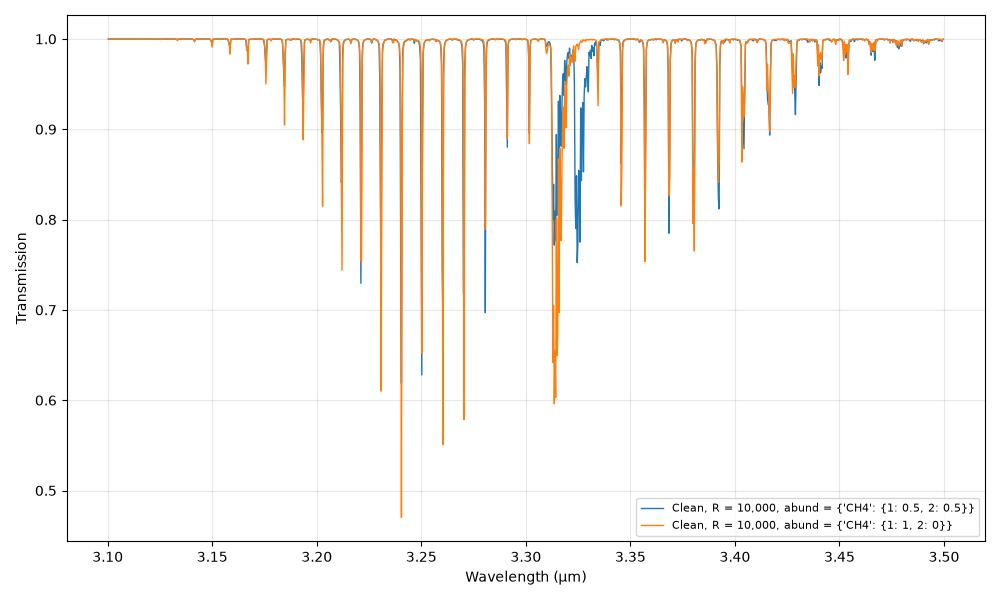

In [125]:
cases = [
    # {'resolution': 1000,  'snr': 50,  'data_abundances': {'CH4': {1: 0.5, 2: 0.5}}},
    {'resolution': 10000, 'snr': 10, 'data_abundances': {'CH4': {1: 0.5, 2: 0.5}}},
    {'resolution': 10000, 'snr': 10, 'data_abundances': {'CH4': {1: 1,2:0}}}
]

plot_spectra_grid(df_results, cases)

## Plotting Results

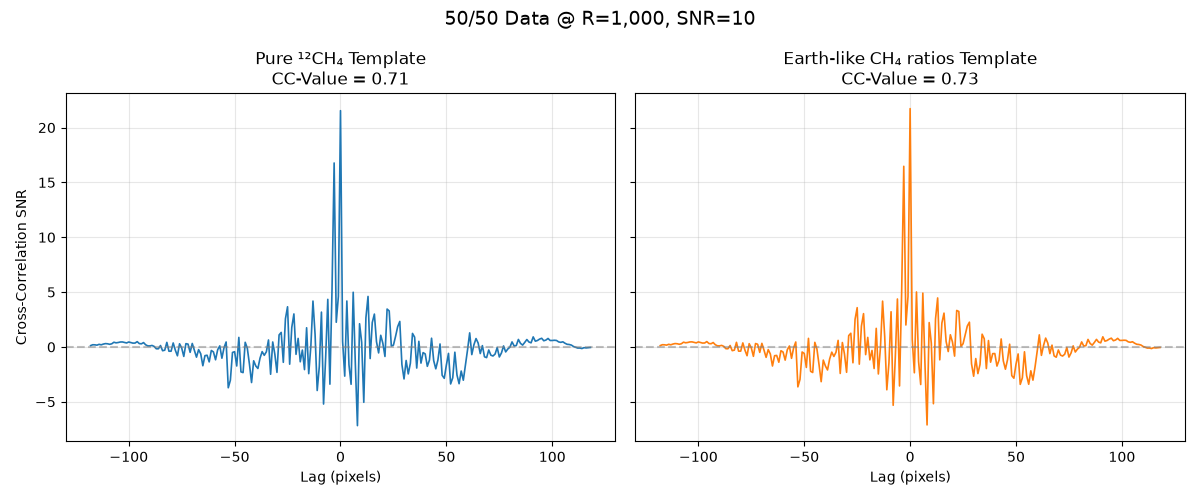

In [111]:
resolution_to_plot = 1000
snr_to_plot = 10

# Define the abundance dictionaries exactly as stored in your DataFrame
pure_template   = {'CH4': {1: 1.0, 2: 0.0}}
earth_template  = {'CH4': {1: 0.95, 2: 0.05}}
test_template = {'CH4': {1:  .9, 2:.1}}
data_5050       = {'CH4': {1: 0.5, 2: 0.5}}

plot_ccf_comparison(
    df=df_results,
    resolution=resolution_to_plot,
    snr=snr_to_plot,
    data_abundances=data_5050,
    template_pure=pure_template,
    template_earth=earth_template, cc_value_plot=False
)

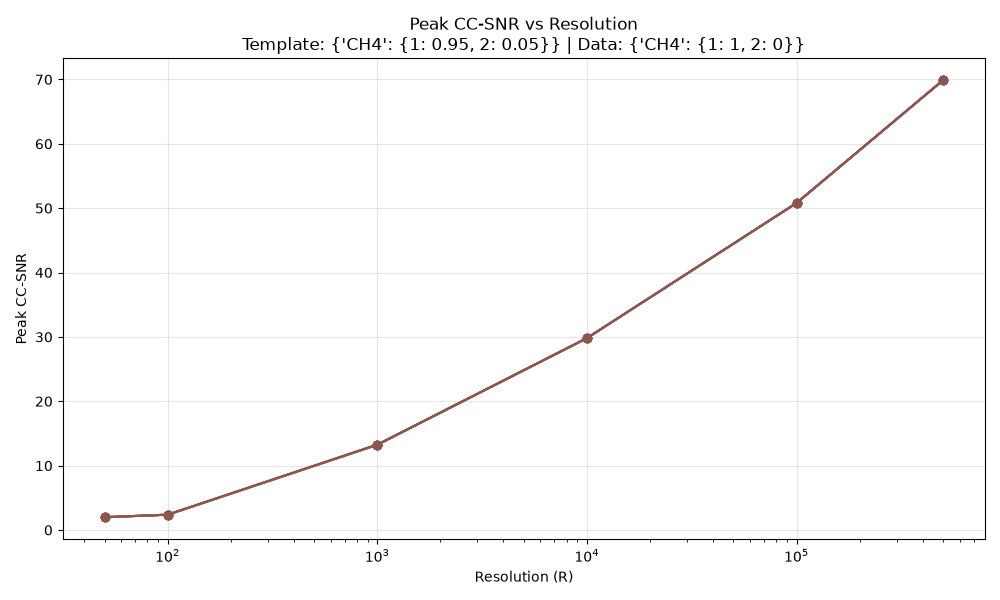

In [112]:
template_abundances_for_plot = {'CH4': {1: 0.95, 2:0.05}}
data_abundances_for_plot = {'CH4': {1: 1, 2: 0}}
snr_to_plot = 5

mask = (
    (df_results['template_abundances'] == template_abundances_for_plot) & 
    (df_results['data_abundances'] == data_abundances_for_plot) & 
    (df_results['snr'] == snr_to_plot)
)
subset = df_results[mask].copy()
subset['peak_cc_snr'] = subset['cc_snr'].apply(np.max)

grouped = subset.groupby('resolution')['peak_cc_snr'].mean().reset_index()

plt.figure(figsize=(10,6))

for res in subset['resolution']:
    plt.plot(grouped['resolution'], grouped['peak_cc_snr'], marker='o', linestyle='-')


plt.xlabel('Resolution (R)')
plt.ylabel('Peak CC-SNR')
plt.title(f'Peak CC-SNR vs Resolution\nTemplate: {template_abundances_for_plot} | Data: {data_abundances_for_plot}')
plt.grid(True, alpha=0.3)
plt.xscale('log')   # Usually helpful for resolution
plt.tight_layout()
plt.show()


### Heatmap

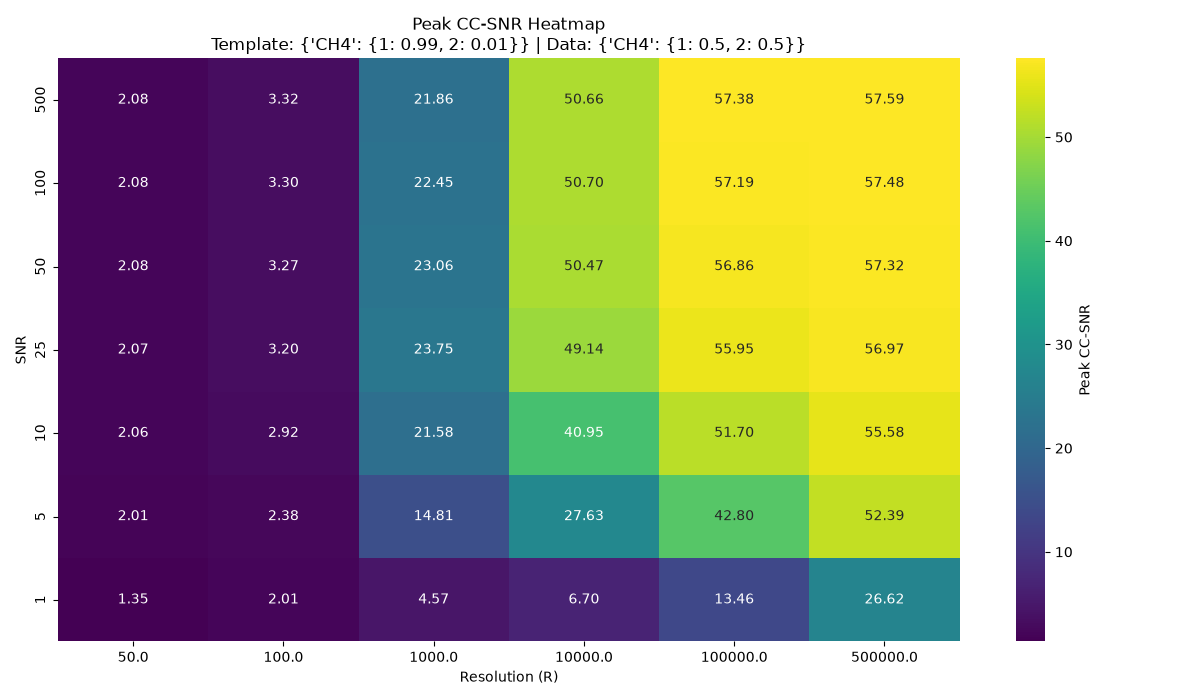

In [113]:
template_abundances_for_plot = {'CH4': {1: .99, 2: .01}}
data_abundances_for_plot = {'CH4': {1: 0.5, 2: 0.5}}

# Filter
mask = (
    (df_results['template_abundances'] == template_abundances_for_plot) & 
    (df_results['data_abundances'] == data_abundances_for_plot)
)
subset = df_results[mask].copy()

# Compute peak CC-SNR per row (since cc_snr is an array)
subset['peak_cc_snr'] = subset['cc_snr'].apply(np.max)

# Create pivot table for heatmap
pivot = subset.pivot_table(
    index='snr', 
    columns='resolution', 
    values='peak_cc_snr', 
    aggfunc='max'          # or 'max' if you prefer
)

# Sort axes nicely
pivot = pivot.sort_index(axis=0).sort_index(axis=1)
pivot = pivot.sort_index(ascending=False)
# ======================
# Plot Heatmap
# ======================
plt.figure(figsize=(12, 7))

sns.heatmap(
    pivot, 
    cmap='viridis',           # or 'plasma', 'inferno', 'coolwarm'
    annot=True,               # show numbers in cells
    fmt=".2f", 
    # linewidths=0.5,
    cbar_kws={'label': 'Peak CC-SNR'}
)

plt.xlabel('Resolution (R)')
plt.ylabel('SNR')
plt.title(f'Peak CC-SNR Heatmap\nTemplate: {template_abundances_for_plot} | Data: {data_abundances_for_plot}')

plt.tight_layout()
plt.show()

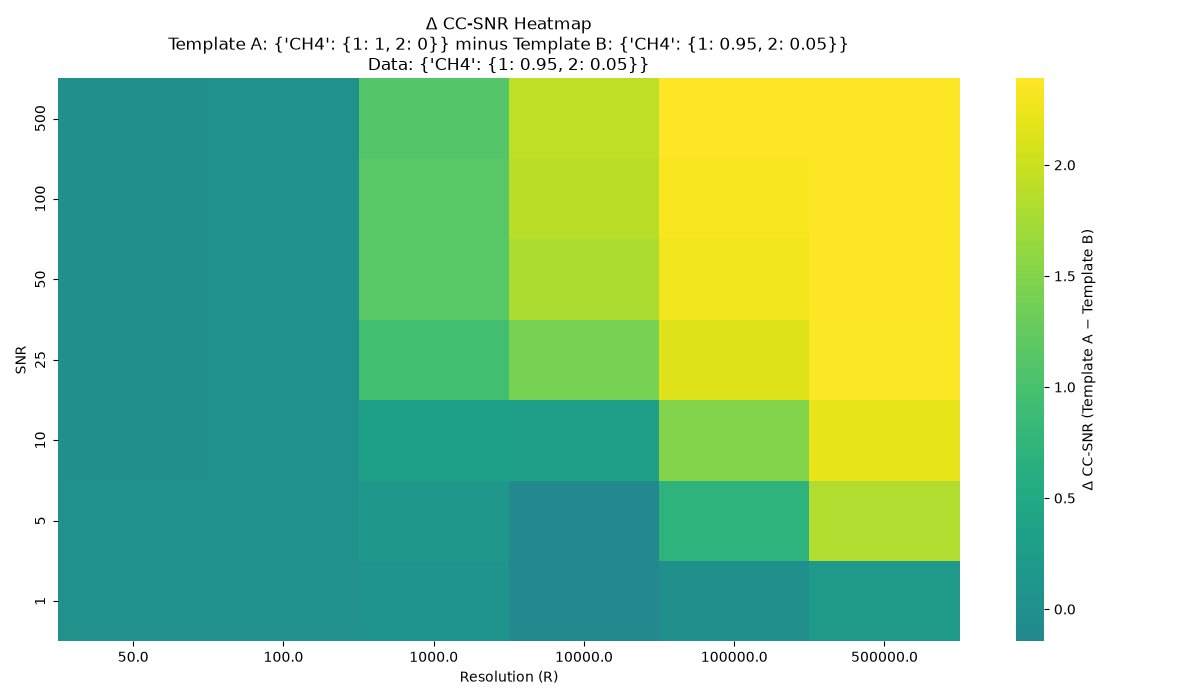

In [115]:
template_A = {'CH4': {1: 1, 2: 0}}   # e.g. 
template_B = {'CH4': {1: 0.95,  2: 0.05}}    #

data_abundances = {'CH4': {1: 0.95, 2: 0.05}}   # The data you're testing against

# ======================
# Extract data for both templates
# ======================
def get_peak_cc_snr(df, template_abundances, data_abundances):
    mask = (
        (df['template_abundances'] == template_abundances) & 
        (df['data_abundances'] == data_abundances)
    )
    subset = df[mask].copy()
    subset['peak_cc_snr'] = subset['cc_snr'].apply(np.max)
    return subset[['resolution', 'snr', 'peak_cc_snr']]

df_A = get_peak_cc_snr(df_results, template_A, data_abundances)
df_B = get_peak_cc_snr(df_results, template_B, data_abundances)

# ======================
# Merge and compute difference
# ======================
merged = pd.merge(
    df_A, 
    df_B, 
    on=['resolution', 'snr'], 
    suffixes=('_A', '_B')
)

merged['delta_cc_snr'] = merged['peak_cc_snr_A'] - merged['peak_cc_snr_B']

# ======================
# Create pivot table for heatmap
# ======================
pivot = merged.pivot_table(
    index='snr', 
    columns='resolution', 
    values='delta_cc_snr',
    aggfunc='mean'
)

# Make SNR increase upward
pivot = pivot.sort_index(ascending=False)

# ======================
# Plot Heatmap
# ======================
plt.figure(figsize=(12, 7))

sns.heatmap(
    pivot,
    cmap='viridis',           # Red = Template A better, Blue = Template B better
    center=0,                # Center colorbar at 0
    # annot=True,
    fmt=".2f",
    # linewidths=0.5,
    cbar_kws={'label': 'Δ CC-SNR (Template A − Template B)'}
)

plt.xlabel('Resolution (R)')
plt.ylabel('SNR')
plt.title(
    f'Δ CC-SNR Heatmap\n'
    f'Template A: {template_A} minus Template B: {template_B}\n'
    f'Data: {data_abundances}'
)

plt.tight_layout()
plt.show()

In [116]:
print(merged.groupby('resolution')[['peak_cc_snr_A', 'peak_cc_snr_B']].mean())

            peak_cc_snr_A  peak_cc_snr_B
resolution                              
50.0             1.958085       1.954608
100.0            2.940425       2.932823
1000.0          25.458789      24.758025
10000.0         51.370816      50.366292
100000.0        63.874006      62.255808
500000.0        70.754990      68.790469
